In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../DATA/combined_cycle_powerplant.csv')

In [3]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


## Пояснение к данным:
    1. AT - температура воздуха в цельсиях
    2. V - давление вакуума на выходе из тубины
    3. AP - атмосферное давление
    4. RH - относительная влажность воздуха в процентах
    5. PE - таргет, выработка энергии

## ВСЯ РАБОТА

In [4]:
columns = {
    'AT': 'Temperature',
    'V': 'Exhaust_Vacuum',
    'AP': 'Ambient_Pressure',
    'RH': 'Relative_Humidity',
    'PE': 'Energy'
}

In [5]:
df = df.rename(columns=columns)

In [6]:
df.head()

,Temperature,Exhaust_Vacuum,Ambient_Pressure,Relative_Humidity,Energy
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9568 entries, 0 to 9567
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Temperature        9568 non-null   float64
 1   Exhaust_Vacuum     9568 non-null   float64
 2   Ambient_Pressure   9568 non-null   float64
 3   Relative_Humidity  9568 non-null   float64
 4   Energy             9568 non-null   float64
dtypes: float64(5)
memory usage: 373.9 KB


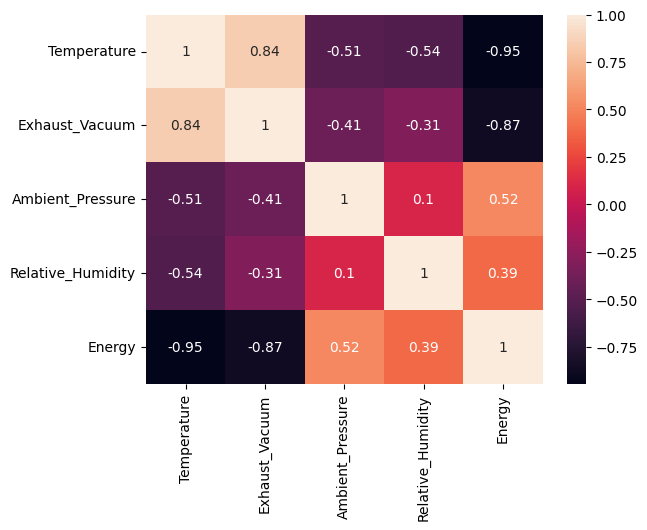

In [8]:
sns.heatmap(df.corr(), annot=True);

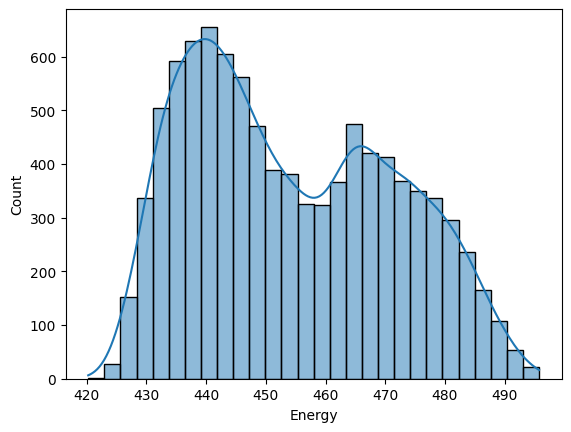

In [9]:
sns.histplot(df['Energy'], kde=True);

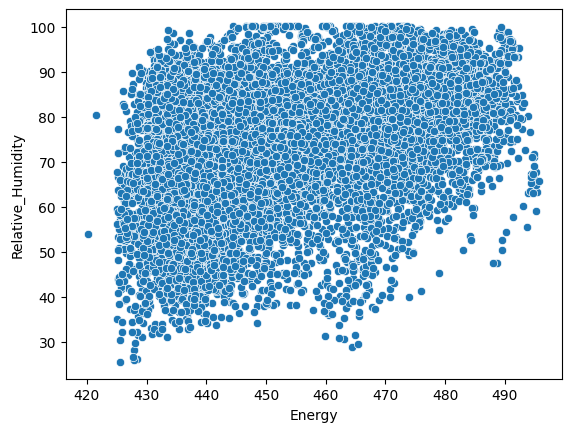

In [10]:
sns.scatterplot(x='Energy', y='Relative_Humidity', data=df);

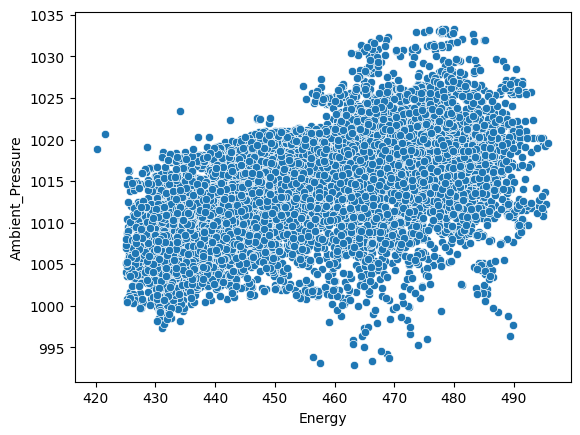

In [11]:
sns.scatterplot(x='Energy', y='Ambient_Pressure', data=df);

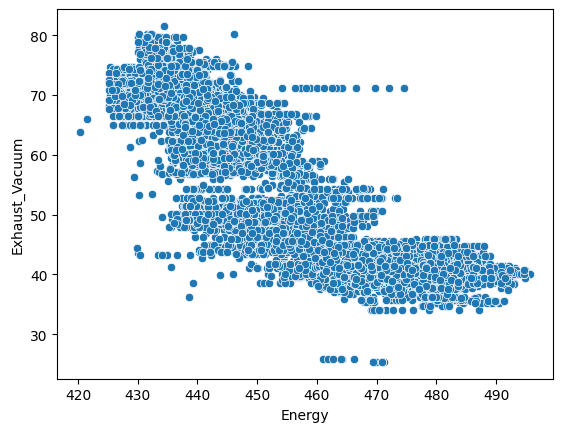

In [12]:
sns.scatterplot(x='Energy', y='Exhaust_Vacuum', data=df);

In [13]:
df[df['Exhaust_Vacuum'] < 30]

,Temperature,Exhaust_Vacuum,Ambient_Pressure,Relative_Humidity,Energy
1013,11.30,25.36,1008.66,96.18,471.19
1248,16.61,25.88,1009.34,65.47,460.97
1360,16.16,25.88,1009.58,72.24,461.86
1377,10.94,25.36,1009.47,100.10,470.90
3866,15.29,25.88,1009.21,66.00,464.25
4015,11.47,25.36,1008.27,95.40,469.51
4174,11.24,25.36,1009.26,97.47,469.92
4483,10.73,25.36,1009.35,100.15,469.43
5079,14.57,25.88,1008.92,69.16,464.11
5204,15.93,25.88,1009.45,72.83,462.70


In [14]:
df = df.drop([1013, 1248, 1360, 1377, 3866, 4015, 4174, 4483, 5079, 5204, 5950, 6085, 6460])

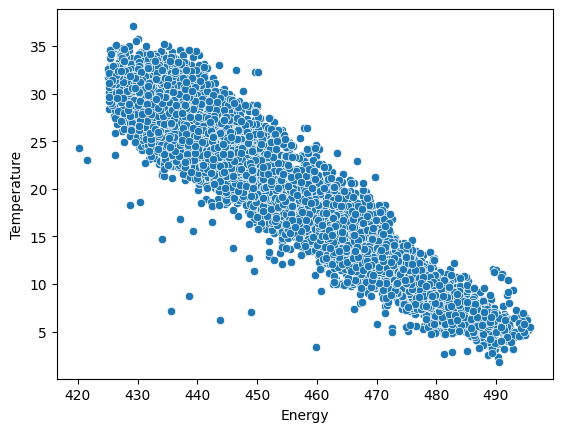

In [15]:
sns.scatterplot(x='Energy', y='Temperature', data=df);

In [16]:
df[(df['Temperature'] < 10) & (df['Energy'] <= 460)]

,Temperature,Exhaust_Vacuum,Ambient_Pressure,Relative_Humidity,Energy
1580,8.74,36.30,1015.18,61.97,438.63
2205,6.22,39.85,1012.05,86.88,443.73
3023,3.40,39.64,1011.10,83.43,459.86
3230,7.14,41.22,1016.60,97.09,435.58
5948,7.06,41.74,1021.95,90.38,448.97


In [17]:
df = df.drop([1580, 2205, 3023, 3230, 5948])

In [18]:
df[(df['Temperature'] < 25) & (df['Energy'] <= 425)]

,Temperature,Exhaust_Vacuum,Ambient_Pressure,Relative_Humidity,Energy
3764,23.00,66.05,1020.61,80.29,421.57
6560,24.27,63.87,1018.88,53.96,420.26


In [19]:
df = df.drop([3764, 6560])

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import ElasticNetCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.impute import KNNImputer

In [21]:
X = df.drop('Energy', axis=1)

In [22]:
y = df['Energy']

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=104)

In [24]:
num_features = X_train.columns.tolist()

In [25]:
pipe = Pipeline([
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler_2', StandardScaler()),
    ('model', ElasticNetCV(cv=10, l1_ratio=[1.0], n_jobs=-1, max_iter=100_00))
])

In [26]:
pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan or None, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`should be set to np.nan, since `pd.NA` will be converted to np.nan.",nan
,"n_neighbors n_neighbors: int, default=5Number of neighboring samples to use for imputation.",5
,"weights weights: {'uniform', 'distance'} or callable, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- callable : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.",'uniform'
,"metric metric: {'nan_euclidean'} or callable, default='nan_euclidean'Distance metric for searching neighbors. Possible values:- 'nan_euclidean'- callable : a user-defined function which conforms to the definition of ``func_metric(x, y, *, missing_values=np.nan)``. `x` and `y` corresponds to a row (i.e. 1-D arrays) of `X` and `Y`, respectively. The callable should returns a scalar distance value.",'nan_euclidean'
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto theoutput of the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear on themissing indicator even if there are missing values at transform/testtime.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0`... versionadded:: 1.2",Fals

In [27]:
y_pred = pipe.predict(X_test)
y_train_pred = pipe.predict(X_train)

In [28]:
best_model = pipe.named_steps['model']
print(f"Лучшее значение alpha: {best_model.alpha_}")
print(f"Лучшее значение l1_ratio: {best_model.l1_ratio_}")

Лучшее значение alpha: 0.016213105841394893
Лучшее значение l1_ratio: 1.0


In [29]:
MAE = mean_absolute_error(y_test, y_pred)
MSE = mean_squared_error(y_test, y_pred)
RMSE = np.sqrt(MSE)
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_pred)

In [30]:
MAE

3.476678530546892

In [31]:
MSE

18.364262562960125

In [32]:
RMSE

np.float64(4.285354426761003)

In [33]:
r2_train

0.94173124416264

In [34]:
r2_test

0.9366591886869986

In [35]:
df['Energy'].mean()

np.float64(454.35932551319644)

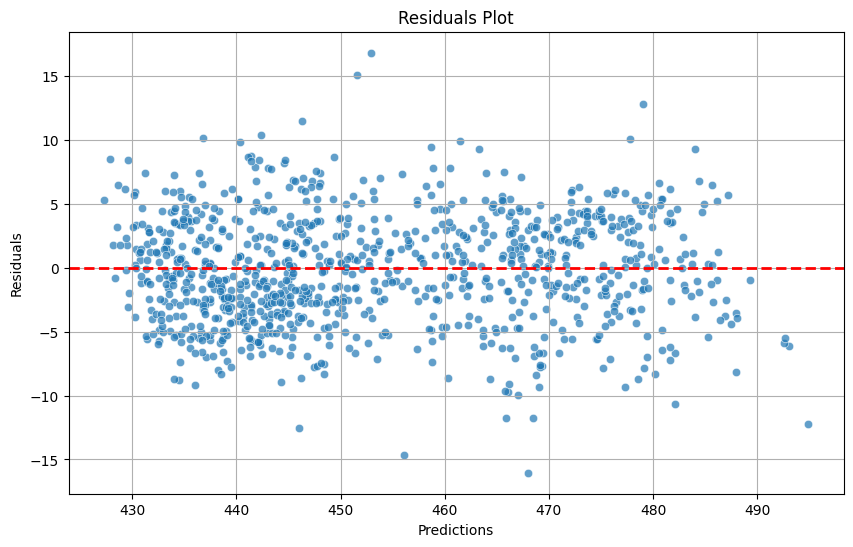

In [36]:
residuals = y_test - y_pred

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)

plt.title('Residuals Plot')
plt.xlabel('Predictions')
plt.ylabel('Residuals')
plt.grid(True)

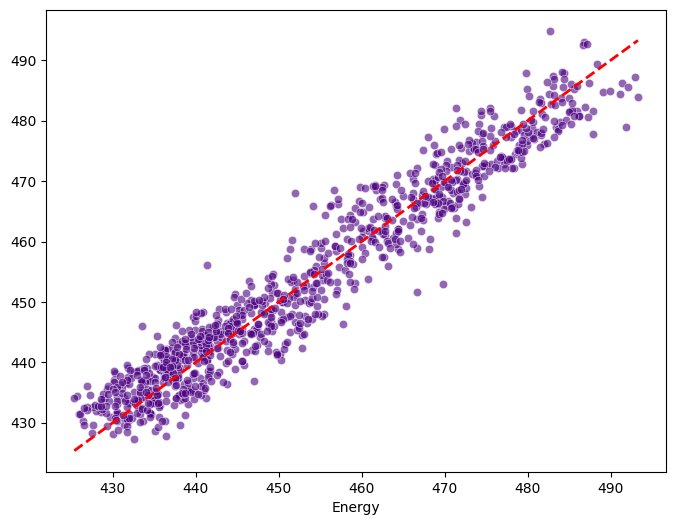

In [37]:
plt.figure(figsize=(8, 6))

sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, color='indigo')

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2);

In [38]:
pipe.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan or None, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`should be set to np.nan, since `pd.NA` will be converted to np.nan.",nan
,"n_neighbors n_neighbors: int, default=5Number of neighboring samples to use for imputation.",5
,"weights weights: {'uniform', 'distance'} or callable, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- callable : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.",'uniform'
,"metric metric: {'nan_euclidean'} or callable, default='nan_euclidean'Distance metric for searching neighbors. Possible values:- 'nan_euclidean'- callable : a user-defined function which conforms to the definition of ``func_metric(x, y, *, missing_values=np.nan)``. `x` and `y` corresponds to a row (i.e. 1-D arrays) of `X` and `Y`, respectively. The callable should returns a scalar distance value.",'nan_euclidean'
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto theoutput of the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear on themissing indicator even if there are missing values at transform/testtime.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0`... versionadded:: 1.2",Fals

In [39]:
y_pred_full = pipe.predict(X)

In [40]:
best_final_model = pipe.named_steps['model']
print(f"Лучшее значение alpha: {best_final_model.alpha_}")
print(f"Лучшее значение l1_ratio: {best_final_model.l1_ratio_}")

Лучшее значение alpha: 0.01620811118578594
Лучшее значение l1_ratio: 1.0


In [41]:
r2_full = r2_score(y, y_pred_full)

In [42]:
r2_full

0.9412534690155246

In [43]:
test_powerplant = pd.DataFrame(
    [
        {
            "Temperature": 5.5,
            "Exhaust_Vacuum": 40.2,
            "Ambient_Pressure": 1025.0,
            "Relative_Humidity": 85.0,
        },
        {
            "Temperature": 45.8,
            "Exhaust_Vacuum": 82.4,
            "Ambient_Pressure": 990.0,
            "Relative_Humidity": 30.0,
        },
    ]
)

In [44]:
test_powerplant

,Temperature,Exhaust_Vacuum,Ambient_Pressure,Relative_Humidity
0,5.5,40.2,1025.0,85.0
1,45.8,82.4,990.0,30.0


In [45]:
power_preds = pipe.predict(test_powerplant)

In [46]:
print(f"1. Предсказанная энергия ЗИМОЙ: {power_preds[0]:.2f} МВт")
print(f"2. Предсказанная энергия ЛЕТОМ: {power_preds[1]:.2f} МВт")

1. Предсказанная энергия ЗИМОЙ: 486.62 МВт
2. Предсказанная энергия ЛЕТОМ: 410.92 МВт


In [47]:
import json
import os

advanced_report = {
    "project": "Combined Cycle Powerplant Energy Prediction",
    "model": "ElasticNetCV",
    "trained_date": '2026-07',
    "test_parameters": {
        "alpha": best_model.alpha_,
        "l1_ratio": best_model.l1_ratio_,
        "cv": best_model.cv
    },
    "final_parameters": {
        "alpha": best_final_model.alpha_,
        "l1_ratio":  best_final_model.l1_ratio_,
        "cv": best_final_model.cv
    },
    "metrics": {
        "RMSE": RMSE,
        "MAE": MAE,
        "R2_train": r2_train,
        "R2_test": r2_test,
        "R2_full": r2_full,
        "Mean_Combined_Cycle_Powerplant_Energy": df['Energy'].mean()
    }
}


filename = "model_description.json"

with open(filename, "w", encoding="utf-8") as f:
    json.dump(advanced_report, f, indent=4, ensure_ascii=False)

In [48]:
from joblib import dump, load

In [49]:
dump(pipe, 'model/powerplant_energy_predict_elastic_net_cv_2026_v1.pkl')

['model/powerplant_energy_predict_elastic_net_cv_2026_v1.pkl']

In [50]:
loaded_pipe = load('model/powerplant_energy_predict_elastic_net_cv_2026_v1.pkl')

In [51]:
loaded_pipe.predict(test_powerplant)

array([486.61980547, 410.92035849])